In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import json
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns




In [ ]:
ROOT_PATH = "/content/drive/MyDrive/Leukemiadata"

SUBFOLDERS = [
    "H_100X_C1",
    "H_100X_C2",
    "L_100X_C1"
]

OUTPUT_BASE = "/content/leukemia_binary_dataset"
TRAIN_OUT = os.path.join(OUTPUT_BASE, "train")
TEST_OUT = os.path.join(OUTPUT_BASE, "test")




In [ ]:
LEUKEMIA_CLASSES = ["lymphoblast", "monoblast"]
HEALTHY_CLASSES = [
    "lymphocyte",
    "neutrophil",
    "myelocyte",
    "monocyte",
    "eosinophil",
    "basophil"
]

def map_label(category):
    if category.lower() in LEUKEMIA_CLASSES:
        return "leukemia"
    elif category.lower() in HEALTHY_CLASSES:
        return "healthy"
    else:
        return None



In [ ]:
if os.path.exists(OUTPUT_BASE):
    shutil.rmtree(OUTPUT_BASE)

os.makedirs(os.path.join(TRAIN_OUT, "healthy"), exist_ok=True)
os.makedirs(os.path.join(TRAIN_OUT, "leukemia"), exist_ok=True)
os.makedirs(os.path.join(TEST_OUT, "healthy"), exist_ok=True)
os.makedirs(os.path.join(TEST_OUT, "leukemia"), exist_ok=True)


In [ ]:
def process_split(folder, split):
    base = os.path.join(ROOT_PATH, folder)

    image_dir = os.path.join(base, "Images", split)
    json_dir = [d for d in os.listdir(base) if "json" in d.lower()][0]
    json_path = os.path.join(base, json_dir, f"{split}.json")

    with open(json_path, "r") as f:
        data = json.load(f)

    image_id_map = {img["id"]: img["file_name"] for img in data["images"]}

    saved = 0

    for ann in data["annotations"]:
        label = map_label(ann["category_name"])
        if label is None:
            continue

        img_name = image_id_map[ann["image_id"]]
        img_path = os.path.join(image_dir, img_name)

        image = cv2.imread(img_path)
        if image is None:
            continue

        x, y, w, h = map(int, ann["bbox"])
        cell = image[y:y+h, x:x+w]

        if cell.size == 0:
            continue

        cell = cv2.resize(cell, (224, 224))

        out_dir = TRAIN_OUT if split == "train" else TEST_OUT
        save_path = os.path.join(out_dir, label, f"{folder}_{split}_{saved}.jpg")

        cv2.imwrite(save_path, cell)
        saved += 1

    print(f"{folder} | {split}: {saved} images saved")


In [ ]:
for folder in SUBFOLDERS:
    process_split(folder, "train")
    process_split(folder, "test")


H_100X_C1 | train: 3227 images saved
H_100X_C1 | test: 1162 images saved
H_100X_C2 | train: 3258 images saved
H_100X_C2 | test: 1169 images saved
L_100X_C1 | train: 0 images saved
L_100X_C1 | test: 0 images saved


In [ ]:
for cls in ["healthy", "leukemia"]:
    print(
        cls,
        "train:", len(os.listdir(os.path.join(TRAIN_OUT, cls))),
        "test:", len(os.listdir(os.path.join(TEST_OUT, cls)))
    )


healthy train: 2724 test: 1707
leukemia train: 3761 test: 624


In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_OUT,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_OUT,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)


Found 6485 images belonging to 2 classes.
Found 2331 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 2,183,297 (8.33 MB)

 Non-trainable params: 402,880 (1.54 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 583s 3s/step - accuracy: 0.6382 - loss: 0.6327 - val_accuracy: 0.4522 - val_loss: 1.0582
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 559s 3s/step - accuracy: 0.8707 - loss: 0.3200 - val_accuracy: 0.6002 - val_loss: 0.8492
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.8872 - loss: 0.2803 - val_accuracy: 0.7267 - val_loss: 0.5996
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 557s 3s/step - accuracy: 0.8924 - loss: 0.2648 - val_accuracy: 0.8005 - val_loss: 0.4257
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 545s 3s/step - accuracy: 0.9016 - loss: 0.2440 - val_accuracy: 0.8644 - val_loss: 0.3061
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 544s 3s/step - accuracy: 0.9104 - loss: 0.2272 - val_accuracy: 0.8803 - val_loss: 0.2685
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 598s 3s/step - accuracy: 0.9103 - loss: 0.2137 - val_accuracy: 0.8953 - val_loss: 0.2402
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 545s 3s/step - accuracy: 0.9198 - loss: 0.2010 - val_accu

KeyboardInterrupt: 

In [ ]:
y_true = test_data.classes
y_pred = (model.predict(test_data) > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Healthy", "Leukemia"]))


73/73 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step
[[1560  147]
 [  40  584]]
              precision    recall  f1-score   support

     Healthy       0.97      0.91      0.94      1707
    Leukemia       0.80      0.94      0.86       624

    accuracy                           0.92      2331
   macro avg       0.89      0.92      0.90      2331
weighted avg       0.93      0.92      0.92      2331



In [ ]:
model.save("/content/drive/MyDrive/leukemia_binary_best_model.h5")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/leukemia_binary_best_model.h5"
)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

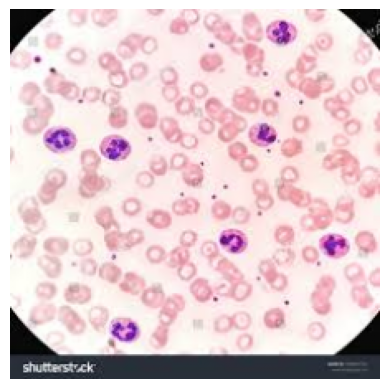

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/test.1.jpg"  # change if needed

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

plt.imshow(img[0])
plt.axis("off")


In [ ]:
pred = model.predict(img)[0][0]

print("Raw probability:", pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Raw probability: 0.89572823


In [ ]:
if pred > 0.5:
    print("Prediction: LEUKEMIA")
else:
    print("Prediction: HEALTHY")


Prediction: LEUKEMIA


In [ ]:
confidence = pred if pred > 0.5 else 1 - pred
print(f"Confidence: {confidence * 100:.2f}%")


Confidence: 89.57%


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

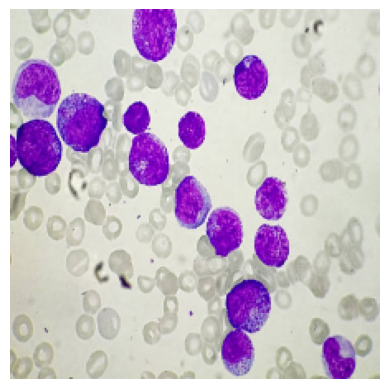

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/test.2.jpg"  # change if needed

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

plt.imshow(img[0])
plt.axis("off")


In [ ]:
pred = model.predict(img)[0][0]

print("Raw probability:", pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Raw probability: 0.8123078


In [ ]:
if pred > 0.5:
    print("Prediction: LEUKEMIA")
else:
    print("Prediction: HEALTHY")


Prediction: LEUKEMIA


In [ ]:
confidence = pred if pred > 0.5 else 1 - pred
print(f"Confidence: {confidence * 100:.2f}%")


Confidence: 81.23%


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

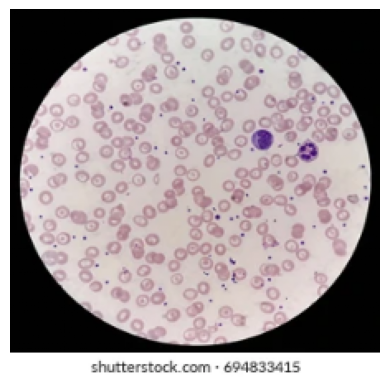

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/test.3.webp"  # change if needed

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

plt.imshow(img[0])
plt.axis("off")
